# Support Vector Machine(SVM)
기계학습 분야 중 하나로 패턴인식, 자료분석을 위한 지도학습 모델분류와 회귀분석을 위해 사용한다.\
선형이나 비선형 분류, 회귀, 이상치 탐색에도 사용가능한 다목적 머신러닝 모델이다.\
이번 포스팅에서는 SVM에 대해 알아보자 

## 선형 SVM 분류
왼쪽 그림은 세개의 선형 분류기를 이용해서 만든 결정경계를 나타낸다. 점선 그래프는 올바르게 클래스를 분류하지 못한다.\
오른쪽 그림의 실선은 SVM 분류기의 결정경계이다. 이 직선은 두개의 클래스를 잘 나누고, 가장 가까운 훈련 샘플로부터 가능한 멀리 떨어져있기 때문에 일반화에 더 용이하다. 

> [!NOTE] 
> 이처럼 SVM 분류기는 클래스 사이에 가장 폭이 넓은, 즉 **margin이 큰 도로를 찾는 것**으로 생각할 수 있다. 
> 그래서 SVM을 Large Margin Classification 이라고도 한다. 

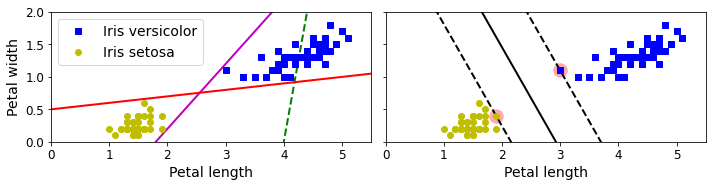

오른쪽 그림처럼 결정된 경계의 바깥쪽에 샘플을 추가해도 결정 경계에는 영향이 없다.\
즉 결정 경계는 경계에 위치한 샘플에 의해 전적으로 결정된다. 이런 샘플을 **서포트 벡터**라고 부른다.\
(오른쪽 그림의 동그라미로 표시된다)

> [!CAUTION]
> SVM의 특성은 scale에 민감하다. 왼쪽 그래프는 수직축의 스케일이 가로축보다 훨씬 커서 margin이 작아진다.\
> 오른쪽 그림처럼 특성의 스케일을 조정하면 결정 경계를 훨씬 좋게 설정할 수 있다.

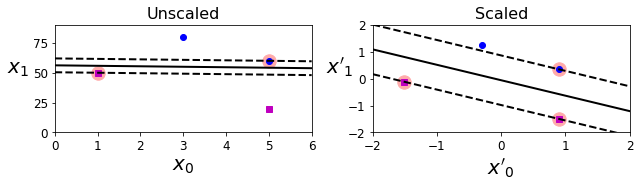

### Hard & Soft Margin 분류
다시 위의 예시로 돌아가보자. 처음 SVM 그래프처럼 모든 샘플이 도로 바깥쪽에 분류되어 있다면 이를 **하드 마진 분류** 라고 한다.\
하지만 하드마진분류에는 두가지 문제점이 있다.
1. 데이터가 선형적으로 구분될 수 있어야 올바르게 동작한다. 
2. 이상치에 민감하다.

아래 그림을 보자. 


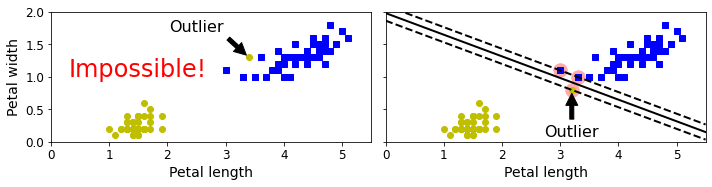

이처럼 왼쪽 그래프에서는 이상치로 인해 하드마진을 찾을 수 없다. 오른쪽 그래프 역시 이상치에 너무 민감하게 반응하여 결정경계의 일반화가 잘 되지 않아보인다.\

이런 문제를 해결하기 위해서 조금 *더 유연한 모델*이 필요하다.
* Margin을 가능한 넓게 유지하는 것과
* Margin 오류 사이의 적절한 균형을 찾아야 한다. 

이를 **소프트 마진 분류**라고 한다.

---

## 비선형 SVM 분류
지금까지는 선형적인 결정경계를 이용해서 분류할 수 있는 선형 SVM 분류기를 알아봤다.\
하지만 실생활에서는 선형적으로 분류할 수 없는 데이터셋이 훨씬 많다.

비선형적인 데이터를 다루는 한가지 방법은 **다항 특성과 같은 특성을 더 추가**하는 것이다. 
그 방법으로 
1. 다항식 커널
2. 유사도 특성

등이 있다.

우선 다항식 특성을 추가해서 선형적으로 구분되는 데이터를 만드는 간단한 예시를 보자.\
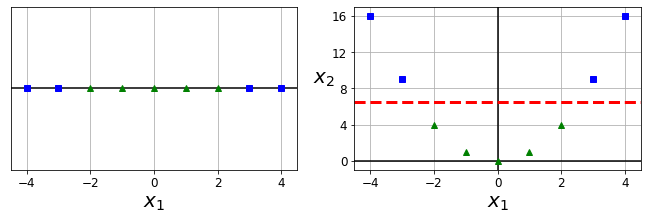

왼쪽 그림 하나의 특성 $x_1$을 가지는 데이터셋으로 선형적으로 구분이 안된다.\
하지만 $x_2=(x_1)^2$ 이라는 새로운 특성 $x_2$를 추가하여 만들어진 오른쪽 그림은 선형적으로 구분할 수 있게 된다.
---

### 다항식 커널
다항식 특성을 추가하는 방법은 다양한 머신러닝 알고리즘에서 잘 작동한다.\
하지만 낮은 차수의 다항식은 복잡한 데이터셋을 잘 표현하지 못하고, 높은 차수의 다항식은 모델을 느리게 만들 수 있다.

SVM에서는 **커널 트릭**이라는 수학적인 기법을 적용해서 실제로는 특성을 추가하지 않으면서도, 다항식 특성을 많이 추가한 것과 같은 결과를 얻을 수 있다[^1].

> [!NOTE]
> 간략히 소개하면 커널 트릭이란 입력 데이터를 고차원 공간으로 변환해서, 선형적으로 구분할 수 없는 데이터를 선형적으로 구분 가능하게 만드는 기법이다.

[^1]: 커널트릭에 대해 잘 정리한 블로그 https://sanghyu.tistory.com/14



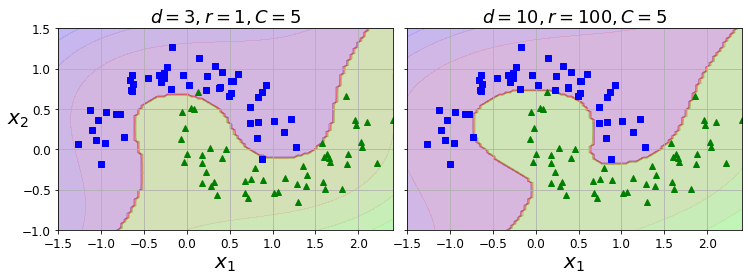

왼쪽 그래프는 3차 다항식 커널을 사용해 훈련한 SVM 분류기이고, 오른쪽 그래프는 10차 다항식 커널을 사용해 훈련한 SVM 분류기 이다.\
만약 모델이 데이터에 overfitting 이면 다항식의 차수를 줄이고 underfitting 이라면 다항식의 차수를 늘려서 조정할 수 있다.

### 유사도 특성
비선형적인 특성을 다루는 또 다른 기법은 각 샘플이 특정 랜드마크와 얼마나 닮았는지 측정하는 **유사도 함수**로 계산한 특성을 추가하는 것이다.\
이 방법 역시 새로운 특성을 추가하는 기법이다. 

앞서 본 간단한 1차원 데이터 셋 예시에서 두개의 랜드마크 $x_1=-2$와 $x_1=1$을 추가해보자. 그리고 $\gamma=0.3$ 인 가우시안 방사기저함수(Radial Basis Function, RBF)를 유사도 함수로 정의하자.

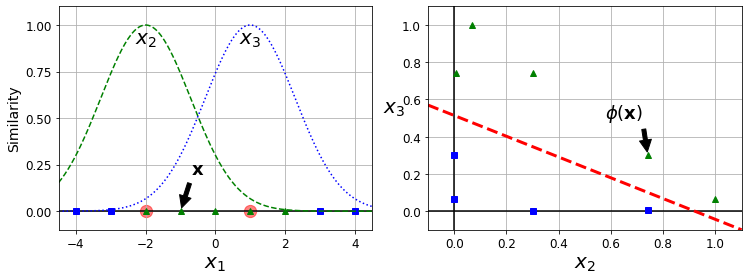

**Equation 5-1: Gaussian RBF**

$
{\displaystyle \phi_{\gamma}(\mathbf{x}, \boldsymbol{\ell})} = {\displaystyle \exp({\displaystyle -\gamma \left\| \mathbf{x} - \boldsymbol{\ell} \right\|^2})}
$


이 함수는 랜드마크와 샘플이 가까울 수록 1, 멀수록 0에 가까운 종과 같은 모양을 그린다.\
즉, 랜드마크와 샘플의 유사도를 나타낸다. 

예를 들어 샘플 $x=-1$을 보면 첫번째 랜드마크와는 1떨어져 있고, 두번째 랜드마크와는 2만큼 떨어져있다.\
따라서 새로 만든 특성은 다음과 같이 두개의 값 $x_2, x_3$으로 나타낼 수 있다.
* $x_2 = exp^{(-0.3*1^2)}=0.74$
* $x_3 = exp^{(-0.3*2^2)}=0.30$

이런 식으로 각 샘플들을 새로운 특성 좌표 $(x_2, x_3)$ 2차원 평면상에 나타낼 수 있고 선형적으로 분류할 수 있게 된다.

> [!NOTE]
> 그렇다면 랜드마크는 어떻게 정할까??\
> 간단한 방법으로는 모든 샘플위치에 랜드마크를 설정할 수 있다. 이렇게 하면 차원이 매우 커지고 데이터 셋이 선형적으로 분류될 가능성이 매우 높지만, 
> 반대로 매우 많은 특성이 만들어지는 단점이 있다.

아래 그래프는 $\gamma$와 C를 바꾸면서 훈련시킨 모델이다.
* $\gamma$를 증가시키면 종 모양 그래프가 좁아져서 각 샘플의 영향 범위가 줄어든다. 즉, 결정경계가 더 데이터에 fit해지고 각 샘플을 따라 구불구불 휘어진다.\
* 반대로 $\gamma$를 감소시키면 넓은 종 모양 그래프로 인해 샘플이 넓은 범위에 영향을 주므로 결정 경계가 부드러워진다. 

따라서 $\gamma$를 조정하여 규제의 역할을 할 수 있고 모델이 과대적합인 경우 $\gamma$를 감소시키고 과소적합인 경우 증가시켜야 한다.
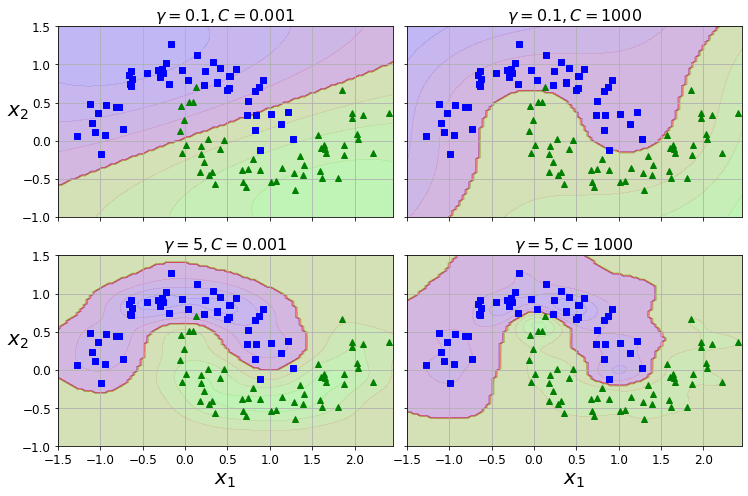